Đang tìm kiếm file CSV...
✅ Đã tìm thấy: 3140 file Fall
✅ Đã tìm thấy: 3848 file No_Fall


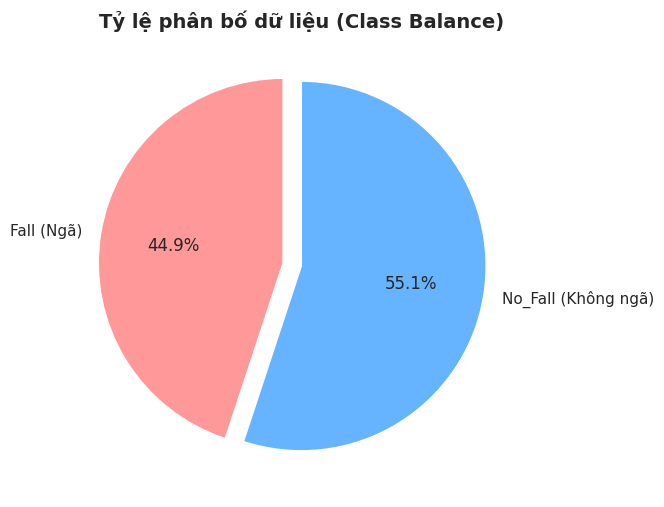

In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo lặt vặt

# Cấu hình giao diện
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("Đang tìm kiếm file CSV...")
# Tự động quét tìm file CSV trong thư mục có chữ 'Fall' và 'No_Fall'
fall_files = glob.glob('/kaggle/input/**/Fall/Keypoints_CSV/*.csv', recursive=True)
no_fall_files = glob.glob('/kaggle/input/**/No_Fall/Keypoints_CSV/*.csv', recursive=True)

n_fall = len(fall_files)
n_no_fall = len(no_fall_files)

print(f"✅ Đã tìm thấy: {n_fall} file Fall")
print(f"✅ Đã tìm thấy: {n_no_fall} file No_Fall")

# KIỂM TRA LỖI TRƯỚC KHI VẼ
if n_fall == 0 and n_no_fall == 0:
    print("❌ LỖI TỘT ĐỘ: Không tìm thấy file nào! Hãy kiểm tra lại dữ liệu đã add vào Kaggle chưa.")
else:
    # Vẽ biểu đồ tròn an toàn
    labels = ['Fall (Ngã)', 'No_Fall (Không ngã)']
    sizes = [n_fall, n_no_fall]
    colors = ['#ff9999','#66b3ff']
    
    plt.figure(figsize=(6, 6))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.1, 0))
    plt.title('Tỷ lệ phân bố dữ liệu (Class Balance)', fontsize=14, fontweight='bold')
    plt.show()

Đang tính toán độ dài các video...


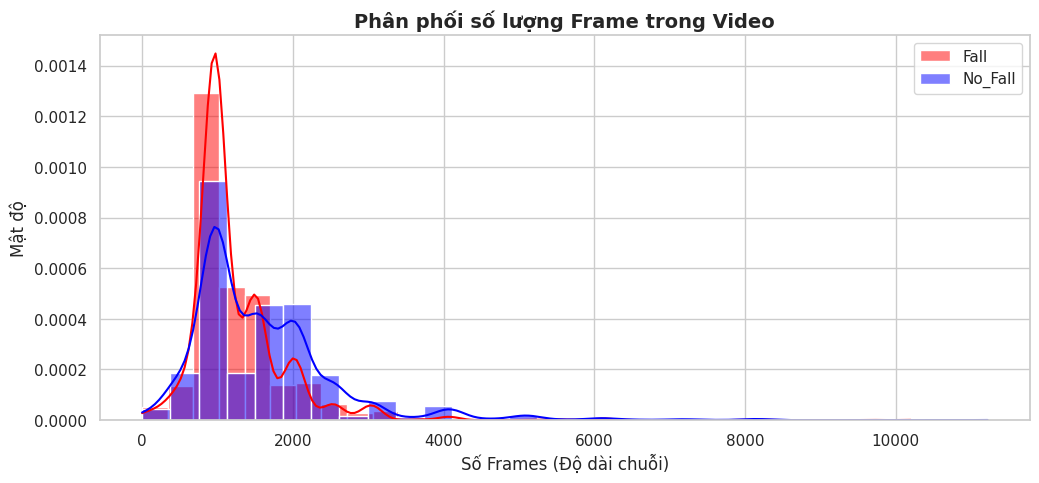

Trung bình số Frame video Ngã: 1251 frames
Trung bình số Frame video Bình thường: 1585 frames


In [4]:
if n_fall > 0 and n_no_fall > 0:
    def get_lengths(file_list):
        lengths = []
        for f in file_list:
            try:
                # Chỉ đọc cột đầu tiên để đếm số dòng cho nhanh, tiết kiệm RAM
                df = pd.read_csv(f, usecols=[0]) 
                lengths.append(len(df))
            except Exception as e:
                pass
        return lengths

    print("Đang tính toán độ dài các video...")
    fall_lengths = get_lengths(fall_files)
    no_fall_lengths = get_lengths(no_fall_files)

    plt.figure(figsize=(12, 5))
    sns.histplot(fall_lengths, color="red", label="Fall", kde=True, stat="density", alpha=0.5, bins=30)
    sns.histplot(no_fall_lengths, color="blue", label="No_Fall", kde=True, stat="density", alpha=0.5, bins=30)

    plt.title('Phân phối số lượng Frame trong Video', fontsize=14, fontweight='bold')
    plt.xlabel('Số Frames (Độ dài chuỗi)', fontsize=12)
    plt.ylabel('Mật độ', fontsize=12)
    plt.legend()
    plt.show()
    
    print(f"Trung bình số Frame video Ngã: {np.mean(fall_lengths):.0f} frames")
    print(f"Trung bình số Frame video Bình thường: {np.mean(no_fall_lengths):.0f} frames")

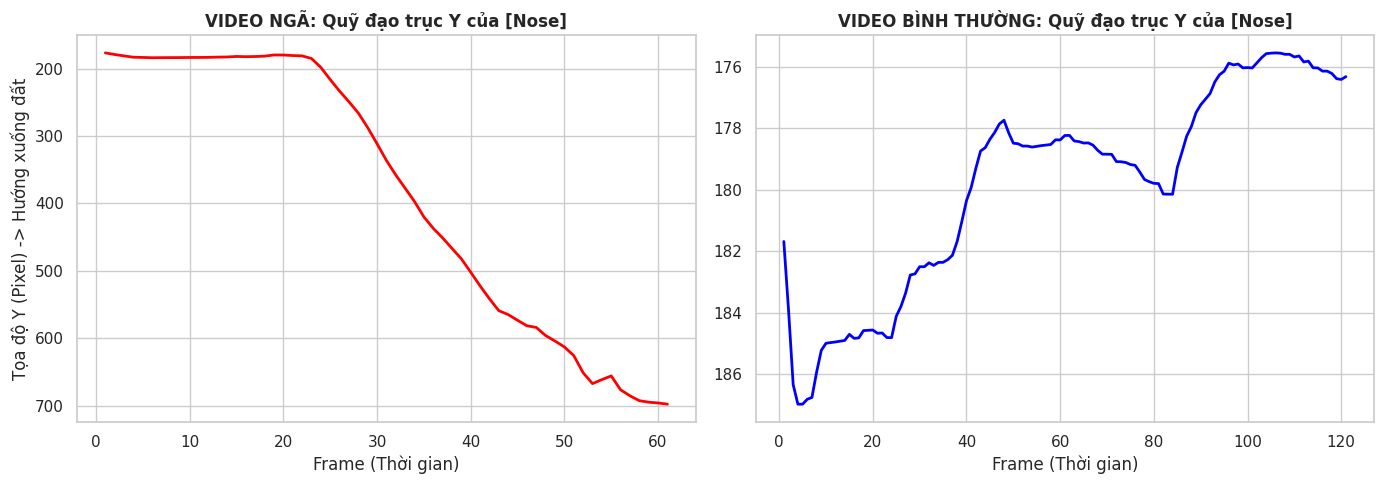

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Giả sử bạn đã load df_fall_sample và df_nofall_sample từ bước 1
# Nếu chưa, hãy load lại 1 file mẫu bất kỳ:
# df_fall_sample = pd.read_csv(fall_files[0])
# df_nofall_sample = pd.read_csv(no_fall_files[0])

# Dọn dẹp tên cột (phòng trường hợp có khoảng trắng thừa)
df_fall_sample.columns = df_fall_sample.columns.str.strip()
df_nofall_sample.columns = df_nofall_sample.columns.str.strip()

# Chọn khớp để theo dõi (Khuyên dùng 'Nose' - Mũi, hoặc 'Left Hip' - Hông trái)
TARGET_KEYPOINT = 'Nose' 

# Lọc dữ liệu chỉ lấy khớp đã chọn
fall_point = df_fall_sample[df_fall_sample['Keypoint'] == TARGET_KEYPOINT]
nofall_point = df_nofall_sample[df_nofall_sample['Keypoint'] == TARGET_KEYPOINT]

plt.figure(figsize=(14, 5))

# Vẽ biểu đồ Ngã
plt.subplot(1, 2, 1)
plt.plot(fall_point['Frame'], fall_point['Y'], color='red', linewidth=2)
plt.title(f'VIDEO NGÃ: Quỹ đạo trục Y của [{TARGET_KEYPOINT}]', fontweight='bold')
plt.xlabel('Frame (Thời gian)')
plt.ylabel('Tọa độ Y (Pixel) -> Hướng xuống đất')
plt.gca().invert_yaxis() # Lật ngược trục Y để trực quan giống mắt người nhìn (Mặt đất ở dưới)

# Vẽ biểu đồ Không ngã
plt.subplot(1, 2, 2)
plt.plot(nofall_point['Frame'], nofall_point['Y'], color='blue', linewidth=2)
plt.title(f'VIDEO BÌNH THƯỜNG: Quỹ đạo trục Y của [{TARGET_KEYPOINT}]', fontweight='bold')
plt.xlabel('Frame (Thời gian)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

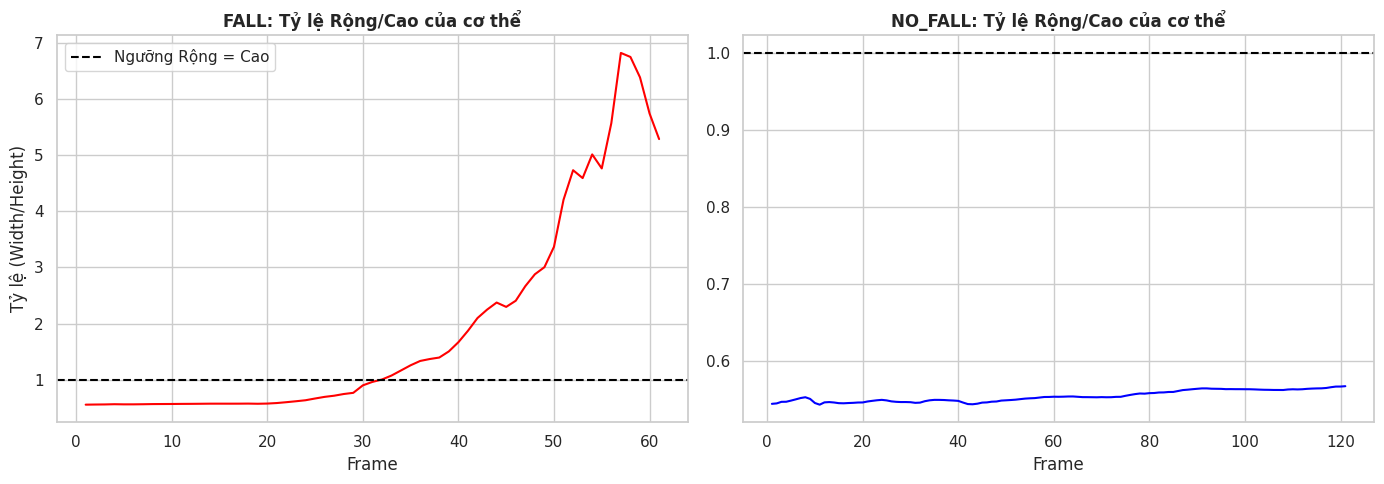

In [10]:
def get_aspect_ratio_from_long_format(df):
    # Loại bỏ các điểm nhiễu (Confidence quá thấp, ví dụ < 0.2)
    # Bước này rất quan trọng để khung bao không bị kéo giãn bởi 1 điểm nhận diện sai
    df_clean = df[df['Confidence'] > 0.2]
    
    ratios = []
    frames = []
    
    # Gom nhóm theo từng Frame
    grouped = df_clean.groupby('Frame')
    
    for frame_id, group in grouped:
        # Lấy giá trị Min, Max của X và Y trong cùng 1 frame
        min_x, max_x = group['X'].min(), group['X'].max()
        min_y, max_y = group['Y'].min(), group['Y'].max()
        
        width = max_x - min_x
        height = max_y - min_y
        
        # Tránh lỗi chia cho 0 nếu frame đó không nhận diện được (Height = 0)
        if height > 0:
            ratio = width / height
        else:
            ratio = 0
            
        ratios.append(ratio)
        frames.append(frame_id)
        
    return frames, ratios

# Tính toán
frames_fall, ratio_fall = get_aspect_ratio_from_long_format(df_fall_sample)
frames_nofall, ratio_nofall = get_aspect_ratio_from_long_format(df_nofall_sample)

# Vẽ biểu đồ
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(frames_fall, ratio_fall, color='red')
plt.axhline(y=1.0, color='black', linestyle='--', label='Ngưỡng Rộng = Cao')
plt.title('FALL: Tỷ lệ Rộng/Cao của cơ thể', fontweight='bold')
plt.xlabel('Frame')
plt.ylabel('Tỷ lệ (Width/Height)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(frames_nofall, ratio_nofall, color='blue')
plt.axhline(y=1.0, color='black', linestyle='--', label='Ngưỡng Rộng = Cao')
plt.title('NO_FALL: Tỷ lệ Rộng/Cao của cơ thể', fontweight='bold')
plt.xlabel('Frame')

plt.tight_layout()
plt.show()

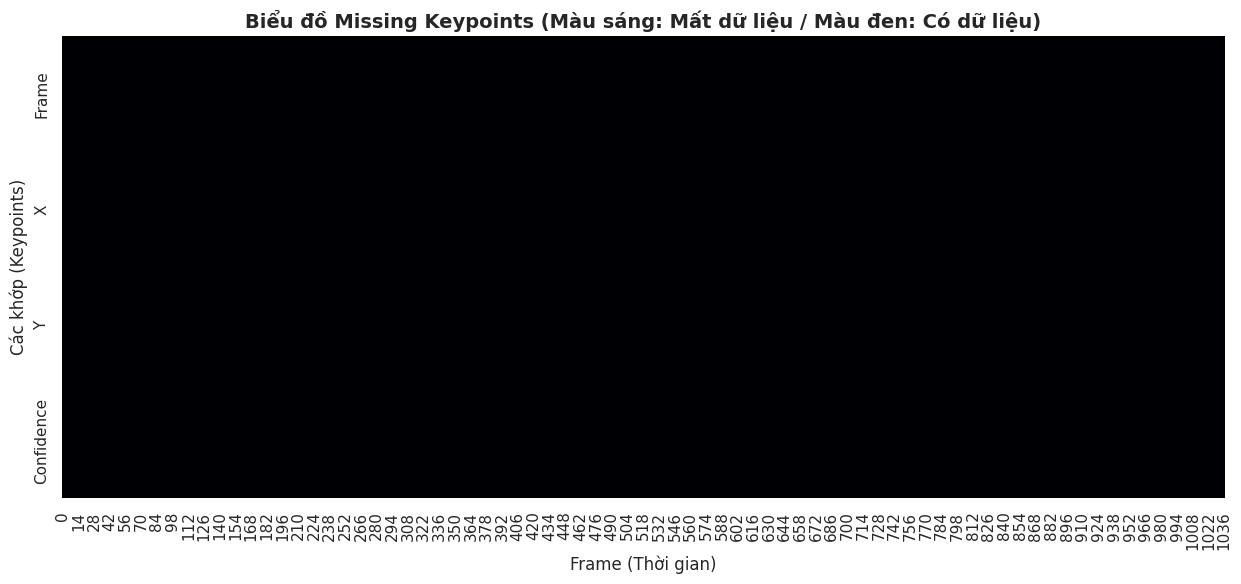

In [8]:
if n_fall > 0:
    plt.figure(figsize=(15, 6))
    
    # Chọn riêng các cột số để kiểm tra null hoặc 0
    numeric_df = df_fall_sample.select_dtypes(include=[np.number])
    
    # Coi giá trị 0 là bị mất dữ liệu (Missing Data)
    missing_data_mask = numeric_df.replace(0, np.nan).isnull().T
    
    sns.heatmap(missing_data_mask, cbar=False, cmap='magma')
    plt.title('Biểu đồ Missing Keypoints (Màu sáng: Mất dữ liệu / Màu đen: Có dữ liệu)', fontsize=14, fontweight='bold')
    plt.xlabel('Frame (Thời gian)')
    plt.ylabel('Các khớp (Keypoints)')
    plt.show()

BẢNG THỐNG KÊ SỐ LƯỢNG DỮ LIỆU:
  Class     Data Type  Count
   Fall     Raw_Video   3140
   Fall Keypoints_CSV   3140
No_Fall     Raw_Video   3848
No_Fall Keypoints_CSV   3848
------------------------------


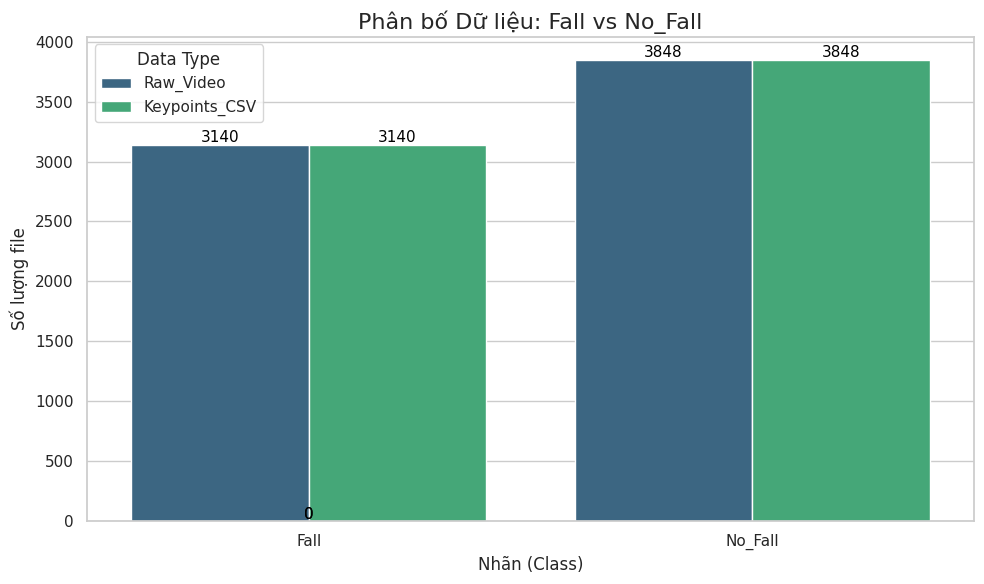

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỊNH NGHĨA ĐƯỜNG DẪN DỮ LIỆU
# LƯU Ý QUAN TRỌNG: Bạn cần copy chính xác đường dẫn của dataset. 
# Cách làm: Trỏ chuột vào chữ "Fall Video Dataset" ở menu bên phải -> Click biểu tượng "Copy file path"
# Thường trên Kaggle nó sẽ có dạng như sau:
BASE_PATH = '/kaggle/input/datasets/payutch/fall-video-dataset' 

# Cấu trúc thư mục dựa theo ảnh của bạn
classes = ['Fall', 'No_Fall']
data_types = ['Raw_Video', 'Keypoints_CSV']

data_counts = []

# 2. ĐẾM SỐ LƯỢNG FILE
for cls in classes:
    for dtype in data_types:
        folder_path = os.path.join(BASE_PATH, cls, dtype)
        
        # Kiểm tra xem thư mục có tồn tại không
        if os.path.exists(folder_path):
            # Đếm số lượng file trong thư mục (bỏ qua các thư mục con nếu có)
            num_files = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
            data_counts.append({'Class': cls, 'Data Type': dtype, 'Count': num_files})
        else:
            print(f"CẢNH BÁO: Không tìm thấy đường dẫn {folder_path}")
            data_counts.append({'Class': cls, 'Data Type': dtype, 'Count': 0})

# Chuyển thành DataFrame để dễ nhìn
df = pd.DataFrame(data_counts)
print("BẢNG THỐNG KÊ SỐ LƯỢNG DỮ LIỆU:")
print(df.to_string(index=False))
print("-" * 30)

# 3. VẼ BIỂU ĐỒ TRỰC QUAN HOÁ
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Class', y='Count', hue='Data Type', palette='viridis')

plt.title('Phân bố Dữ liệu: Fall vs No_Fall', fontsize=16)
plt.xlabel('Nhãn (Class)', fontsize=12)
plt.ylabel('Số lượng file', fontsize=12)

# Thêm số lượng chính xác lên trên cột
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height())}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                       textcoords='offset points')

plt.tight_layout()
plt.show()